<a href="https://colab.research.google.com/github/kauya02053-sketch/Stock-Analysis/blob/main/Stock-Portfolio-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_428/2268593870.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_id, start="2024-01-01")
[*********************100%***********************]  1 of 1 completed


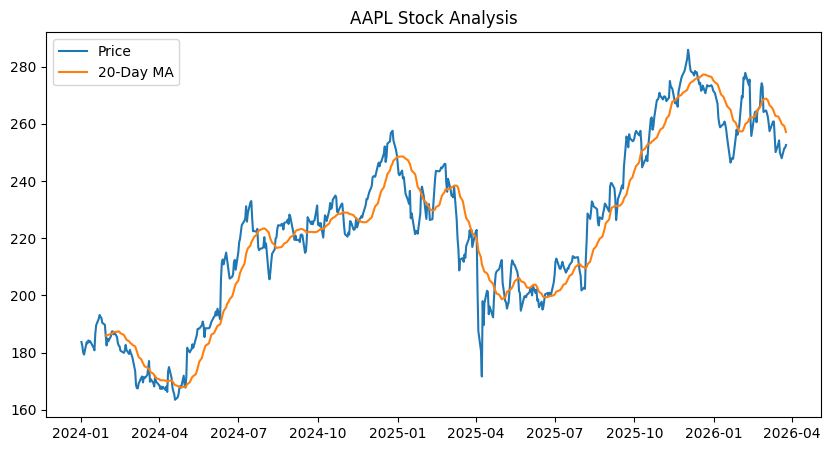

TypeError: unsupported format string passed to Series.__format__

In [ ]:
# 1. 安裝與匯入工具
!pip install yfinance matplotlib -q
import yfinance as yf
import matplotlib.pyplot as plt

# 2. 設定你要分析的股票代號 (例如: AAPL 或 2330.TW)
stock_id = 'AAPL'
data = yf.download(stock_id, start="2024-01-01")

# 3. 簡單分析：計算 20 日均線
data['MA20'] = data['Close'].rolling(window=20).mean()

# 4. 畫圖：房價走勢與均線
plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Price')
plt.plot(data['MA20'], label='20-Day MA')
plt.title(f'{stock_id} Stock Analysis')
plt.legend()
plt.show()

# 5. 結論結論輸出
current_price = data['Close'].iloc[-1]
ma_price = data['MA20'].iloc[-1]
print(f"當前價格: {current_price:.2f}, 20日均線: {ma_price:.2f}")
print("建議: " + ("看多 (價格在均線上)" if current_price > ma_price else "看空 (價格在均線下)"))
plt.savefig('result.png') # 這會把圖存成圖片檔



/tmp/ipykernel_1246/3765560214.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stocks, start=start_date)['Close']
[*********************100%***********************]  4 of 4 completed


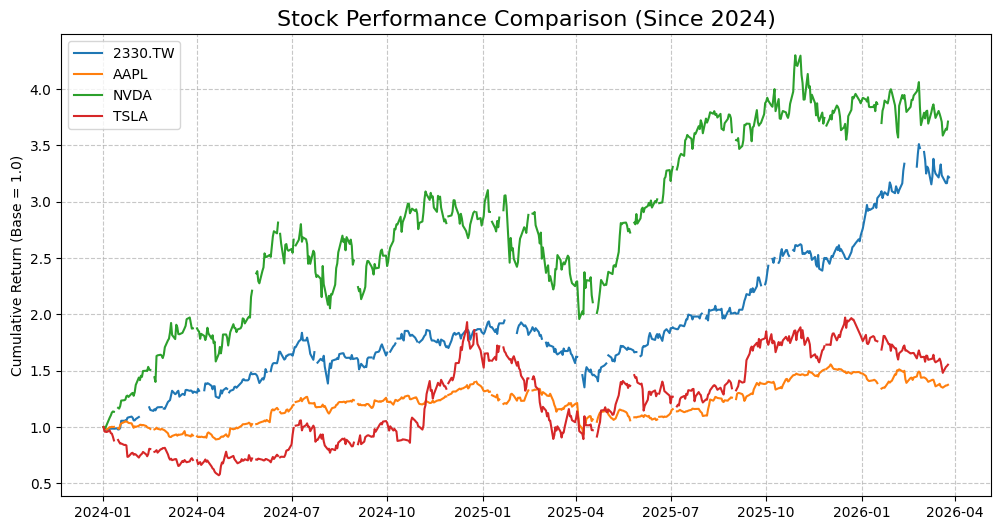

--- 各檔股票累計漲跌幅 ---
Ticker
2330.TW    221.74%
AAPL          nan%
NVDA          nan%
TSLA          nan%
Name: 2026-03-26 00:00:00, dtype: object


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. 設定你想比較的股票代號 (美股或台股均可)
stocks = ['AAPL', 'NVDA', 'TSLA', '2330.TW']
start_date = '2024-01-01'

# 2. 一次抓取所有數據
df = yf.download(stocks, start=start_date)['Close']

# 3. 計算「累積報酬率」 (基準點都從 1 開始，方便比較)
# 公式: 當前價格 / 第一天價格
returns = df / df.iloc[0]

# 4. 畫出超專業的對比圖
plt.figure(figsize=(12, 6))
for column in returns.columns:
    plt.plot(returns[column], label=column)

plt.title('Stock Performance Comparison (Since 2024)', fontsize=16)
plt.ylabel('Cumulative Return (Base = 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. 快速產出績效表格
final_return = (returns.iloc[-1] - 1) * 100
print("--- 各檔股票累計漲跌幅 ---")
print(final_return.sort_values(ascending=False).map("{:.2f}%".format))
